# Data Wrangling and Data Analysis
## Week 5: Data Preparation
### Day 1
#### Working with Missing Values and Outlier Detection 

For this Tutorial, you need to install the following libraries:
* matplotlib
* sklearn


In [1]:
import pandas as pd
import numpy as np

We begin by defining a pandas dataframe that contains some cells with missing values. Note that pandas, in addition to allowing us to create dataframes from a variety of files, also supports explicit declaration.

In [3]:
incomplete_df = pd.DataFrame({'id': [1,2,3,2,2,3,1,1,1,2,4],
                              'type': ['one', 'one', 'two', 'three', 'two', 'three', 'one', 'two', 'one', 'three','one'],
                              'amount': [345,928,'',645,113,942,np.NAN,539,np.NAN,814,np.NAN] 
                             }, columns=['id','type','amount'])

Column 'amount' is the only one with missing values. Now we display the dataframe

Recall that summary statistics and arithmetic with missing data is natively supported by pandas. Let's define two series, both containing some missing values.

In [5]:
A = incomplete_df['amount']
B = pd.Series(data=[np.NAN,125,335,345,312,np.NAN,np.NAN,129,551,800,222])

In [7]:
#TODO: print the content of A
print("The values of attr. A = ", A)
print ('\n')

#TODO: print the content of B
print(B)

The values of attr. A =  0     345.0
1     928.0
2       NaN
3     645.0
4     113.0
5     942.0
6       NaN
7     539.0
8       NaN
9     814.0
10      NaN
Name: amount, dtype: float64


0       NaN
1     125.0
2     335.0
3     345.0
4     312.0
5       NaN
6       NaN
7     129.0
8     551.0
9     800.0
10    222.0
dtype: float64


The mean is computed normally and missing values are ignored:

In [9]:
# TODO: Compute and print the mean value of A
A.mean()

618.0

In [10]:
# TODO: Compute and print the mean value of A using numpy library
np.mean(A)

618.0

Min, Max, STD and Variance all work even when data are missing:

In [12]:
# TDOD: Compute and display the min, max, standard deviation and variance of B
print(B.min())
print(B.max())
print(B.std())
print(B.var())
print(np.min(B))

125.0
800.0
226.90459763647678
51485.69642857143
125.0


In [16]:
# We can also display multiple variable by listing their in a comma separated format e.g. 
#  x, y will display the values of x and y. 
# Use the same format to display the computed quantities
B.min(), B.max(), B.std(), B.var()

(125.0, 800.0, 226.90459763647678, 51485.69642857143)

We can also perform element-wise arithmetic operations between series with missing data. 

Remember: by definition, the result of any operation that involves missing values is NaN.

In [17]:
# TODO: Perform element-wise addition between the values in A and B
A + B

0        NaN
1     1053.0
2        NaN
3      990.0
4      425.0
5        NaN
6        NaN
7      668.0
8        NaN
9     1614.0
10       NaN
dtype: float64

In [18]:
np.add(A, B)

0        NaN
1     1053.0
2        NaN
3      990.0
4      425.0
5        NaN
6        NaN
7      668.0
8        NaN
9     1614.0
10       NaN
dtype: float64

#### Handling the missing values

First, deleting the records that contain missing values 

Pandas has a function that allows deleting the rows in a dataframe (or elements in a series) that contain missing values.

In [19]:
# TODO: Copy the incoomplete dataframe and 
# use a Python function to delete the records with missing values
idf_copy = incomplete_df.copy()
idf_copy.dropna()

,id,type,amount
0,1,one,345.0
1,2,one,928.0
3,2,three,645.0
4,2,two,113.0
5,3,three,942.0
7,1,two,539.0
9,2,three,814.0


In [20]:
# TODO: Now, try the same function on the series A and B
# Print the values of attribute A before removing the null values
print("original\n", A)


# TODO: now, print the values of A but without the null values 
print("A after deleting the missing values = \n", A.dropna())

# TODO: do the same for B
print("original\n", B)
print("B after deleting the missing values = \n", B.dropna())

original
 0     345.0
1     928.0
2       NaN
3     645.0
4     113.0
5     942.0
6       NaN
7     539.0
8       NaN
9     814.0
10      NaN
Name: amount, dtype: float64
A after deleting the missing values = 
 0    345.0
1    928.0
3    645.0
4    113.0
5    942.0
7    539.0
9    814.0
Name: amount, dtype: float64
original
 0       NaN
1     125.0
2     335.0
3     345.0
4     312.0
5       NaN
6       NaN
7     129.0
8     551.0
9     800.0
10    222.0
dtype: float64
B after deleting the missing values = 
 1     125.0
2     335.0
3     345.0
4     312.0
7     129.0
8     551.0
9     800.0
10    222.0
dtype: float64


However, very often you may wish to fill in those missing values rather than simply dropping them. Of course, pandas also has that functionality. For example, we could fill missing values with a constant. 
**We do this for exercise only but you will learn later about different techniques for data imputation.**

In [21]:
'''
TODO: replace the missing value with -99 in attribute dcoilwtico
'''
A.fillna(-99)


0     345.0
1     928.0
2     -99.0
3     645.0
4     113.0
5     942.0
6     -99.0
7     539.0
8     -99.0
9     814.0
10    -99.0
Name: amount, dtype: float64

That actually works with any data type.

In [24]:
# TODO: fill the missing values with the string 'unknown' in attribute A
print(A.fillna("unknown"))
A

0       345.0
1       928.0
2     unknown
3       645.0
4       113.0
5       942.0
6     unknown
7       539.0
8     unknown
9       814.0
10    unknown
Name: amount, dtype: object


0     345.0
1     928.0
2       NaN
3     645.0
4     113.0
5     942.0
6       NaN
7     539.0
8       NaN
9     814.0
10      NaN
Name: amount, dtype: float64

As such, we can use this functionality to fill in the gaps with the average value computed across the non-missing values.

In [25]:
# TODO: replace the missing values with the average value of the non-missing values
A.fillna(A.mean())

0     345.0
1     928.0
2     618.0
3     645.0
4     113.0
5     942.0
6     618.0
7     539.0
8     618.0
9     814.0
10    618.0
Name: amount, dtype: float64

In [26]:
# TODO: Use the same technique to replace the missing values 
# in the amount attribute of the incomplete dataframe 
# We create a new copy of the dataframe and work with the copy 
# so we can replace the values in the dataframe
idf = incomplete_df.copy()
idf["amount"].fillna(incomplete_df["amount"].mean(), inplace = True)
idf

,id,type,amount
0,1,one,345.0
1,2,one,928.0
2,3,two,618.0
3,2,three,645.0
4,2,two,113.0
5,3,three,942.0
6,1,one,618.0
7,1,two,539.0
8,1,one,618.0
9,2,three,814.0


In [27]:
incomplete_df

,id,type,amount
0,1,one,345.0
1,2,one,928.0
2,3,two,NaN
3,2,three,645.0
4,2,two,113.0
5,3,three,942.0
6,1,one,NaN
7,1,two,539.0
8,1,one,NaN
9,2,three,814.0


Even better, if we want to fill in the gaps with mean values of corresponding *id's* (recall our initial dataframe printed below), the following two lines of code perform that seemingly complex task.

In [28]:
# Fill in gaps in the 'amount' column with means obtained from corresponding id's in the first column
idf2 = incomplete_df.copy()
idf2["amount"].fillna(idf2.groupby("id")["amount"].\
                               transform("mean"),inplace=True)

# #TODO: display the dataframe. What do you see?
idf2

,id,type,amount
0,1,one,345.0
1,2,one,928.0
2,3,two,942.0
3,2,three,645.0
4,2,two,113.0
5,3,three,942.0
6,1,one,442.0
7,1,two,539.0
8,1,one,442.0
9,2,three,814.0


In [29]:
# TODO: If there is no corresponding id and the cell is still null, 
# simply use the overall mean
# This step should follow the previous step 
idf2["amount"].fillna(idf2["amount"].mean(), inplace=True)
idf2

,id,type,amount
0,1,one,345.0
1,2,one,928.0
2,3,two,942.0
3,2,three,645.0
4,2,two,113.0
5,3,three,942.0
6,1,one,442.0
7,1,two,539.0
8,1,one,442.0
9,2,three,814.0


You can fill values forwards and backwards with the flags *pad* / *ffill* and *bfill* / *backfill*

In [30]:
# TODO: fill the missing values in B with the values in the previous records (no limit)
print (B)
print ('\n')    # line to separate the output
B.fillna(method = 'pad')

0       NaN
1     125.0
2     335.0
3     345.0
4     312.0
5       NaN
6       NaN
7     129.0
8     551.0
9     800.0
10    222.0
dtype: float64




0       NaN
1     125.0
2     335.0
3     345.0
4     312.0
5     312.0
6     312.0
7     129.0
8     551.0
9     800.0
10    222.0
dtype: float64

We can set a limit if we only want to replace consecutive gaps.

In [31]:
# TODO: fill the missing values in B with the value in the next record (the value of a record can be used in the previous record only)
print (B)
print ('\n')    # line to separate the output
B.fillna(method = 'bfill', limit = 1)

0       NaN
1     125.0
2     335.0
3     345.0
4     312.0
5       NaN
6       NaN
7     129.0
8     551.0
9     800.0
10    222.0
dtype: float64




0     125.0
1     125.0
2     335.0
3     345.0
4     312.0
5       NaN
6     129.0
7     129.0
8     551.0
9     800.0
10    222.0
dtype: float64

### Outlier detection

We can use the  Pima Indians Diabetes Dataset (diabetes.csv) to practice on outlier detection

In [2]:
# TODO: read the csv file pid
df_pid = pd.read_csv('diabetes.csv', header = 0,
                 quotechar = '"',sep = ",",
                 na_values = ['na', '-', '.', ''])
df_pid

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [15]:
df_pid.iloc[2].Pregnancies

8.0

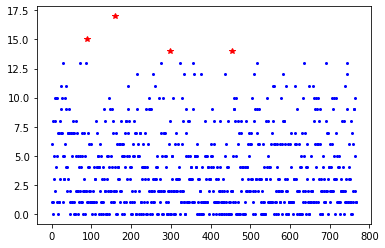

Outliers in column  Pregnancies  are:  {17, 14, 15}


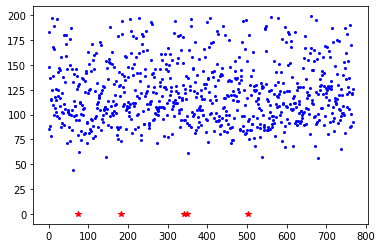

Outliers in column  Glucose  are:  {0}


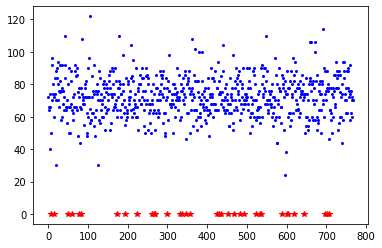

Outliers in column  BloodPressure  are:  {0}


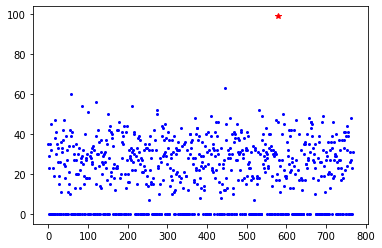

Outliers in column  SkinThickness  are:  {99}


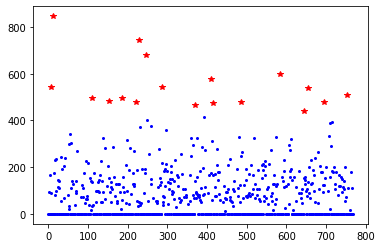

Outliers in column  Insulin  are:  {480, 545, 579, 485, 440, 510, 744, 680, 846, 495, 465, 600, 474, 540, 478, 543}


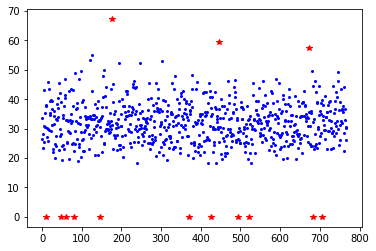

Outliers in column  BMI  are:  {0.0, 59.4, 67.1, 57.3}


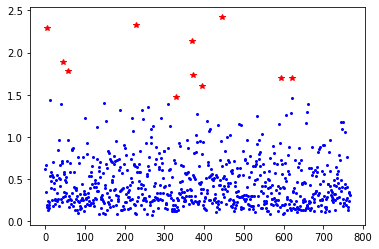

Outliers in column  DiabetesPedigreeFunction  are:  {1.893, 2.288, 2.329, 1.476, 1.781, 2.137, 1.731, 1.6, 2.42, 1.699, 1.698}


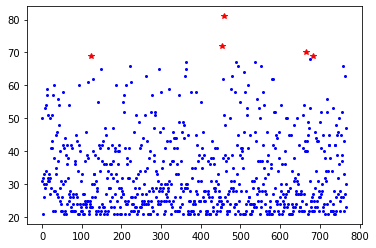

Outliers in column  Age  are:  {72, 81, 69, 70}


In [26]:
# TODO: for each column except the label column, compute the standard deviation of the columns
# report all the values that are at distance > 3 * std from the mean value as outliers.
import matplotlib.pyplot as plt
%matplotlib inline
def stat_outliers (col):
    outliers = set()
    m = col.mean()
    s = col.std()
    for p in col.unique():
        if (abs(p-m) > 3 * s):
            outliers.add(p)
    outliers_indexes = col.isin(outliers)
    plt.plot(col, color='blue', marker='o', ms = 2, linewidth = 0)
    plt.plot(col, color='red', markevery = outliers_indexes, marker='*', ms = 6, linewidth = 0)
    plt.show()
    return outliers

for col in df_pid.columns[:-1]:
    outliers = stat_outliers(df_pid[col])
    print("Outliers in column ", col, " are: ", outliers)
    


In [12]:
col, sum(outliers_indexes)

('Age', 5)

In [16]:
df_pid.loc[df_pid.Age == 70]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
666,4,145,82,18,0,32.5,0.235,70,1


#### Outlier detection using KNN 
Now, we use the k-nearest neighbours method to detect the outliers 

In [1]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
# First, we define a function to find the outlier and 
# plot the data after highlighting the outliers
%matplotlib inline
def knn_outliers(data, threshold):
    nbrs = NearestNeighbors(n_neighbors = 10)
    X = data.reshape(-1, 1)
    # fit model
    nbrs.fit(X)
    # distances and indexes of k-neaighbors from model outputs
    distances, indexes = nbrs.kneighbors(X)
    # plot mean of k-distances of each observation
    plt.plot(distances.mean(axis = 1))
    # visually determine cutoff values > 0.15
    outlier_index = np.where(distances.mean(axis = 1) > threshold)
    knn_outliers = list(outlier_index[0])
    plt.plot(data, color='black', marker='o', ms = 2, linewidth = 0)
    plt.plot(data, markevery = knn_outliers, color='green', marker='s', ms=7, fillstyle='none', linewidth=0)
    plt.show()
    outliers = X[knn_outliers]
    return np.unique(outliers)

In [2]:
# Now, we iterate over the columns and find the outliers in each column
for col in df_pid.columns[:-1]:
    data = np.array(df_pid[col])
    outliers = knn_outliers(data, 0.75, 15)
    print("Attribute {} has {} as outliers".format(col, outliers))
# df_pid.columns

NameError: name 'df_pid' is not defined

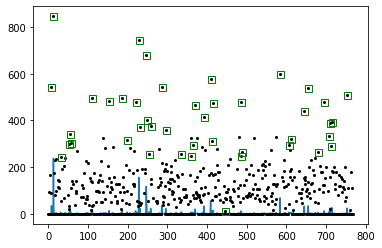

Attribute Insulin has [ 14 245 249 250 255 258 265 291 293 300 304 310 318 321 335 342 360 370
 375 387 392 402 415 440 465 474 478 480 485 495 510 540 543 545 579 600
 680 744 846] as outliers
Number of outliers =  39


In [51]:
# We need to handle the attribute Insulin Separately with different threshold values
col = 'Insulin'
data = np.array(df_pid[col])
outliers = knn_outliers(data, 6)
print("Attribute {} has {} as outliers".format(col, outliers))
print ("Number of outliers = ", len(outliers))

#### Outlier detection using Local Outlier Factor
Now, we use the LOF method to detect the outliers

In [47]:
# TODO: Apply LOF to find outliers in all the columns in the dataframe except the label 
from sklearn.neighbors import LocalOutlierFactor
%matplotlib inline

def lof_outliers(data, threshold):
    clf = LocalOutlierFactor(n_neighbors = 10)
    X = data.reshape(-1, 1)
    clf.fit_predict(X)
    lofOutiers = []
    for cc in range(len(clf.negative_outlier_factor_)):
        if clf.negative_outlier_factor_[cc] < -threshold:
            lofOutiers.append(cc)
    plt.plot(data, color='black', marker='o', ms=2, linewidth=0)
    plt.plot(data, markevery = lofOutiers, color='red', marker='s', ms=7, \
             fillstyle='none', linewidth=0)
    plt.show()
    outliers = X[lofOutiers]
    return np.unique(outliers)

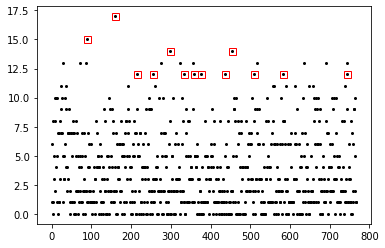

Attribute Pregnancies has [12 14 15 17] as outliers


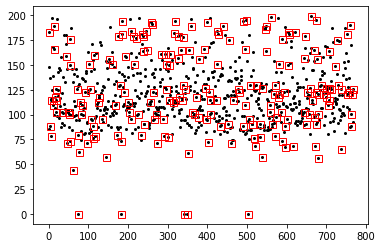

Attribute Glucose has [  0  44  56  57  61  62  65  67  68  71  72  73  76  77  78  79  89  91
  96  98 101 103 110 113 115 118 121 123 126 127 130 149 150 151 156 157
 159 160 161 164 165 166 175 176 177 178 179 181 182 183 184 186 189 190
 191 193 194 195 198 199] as outliers


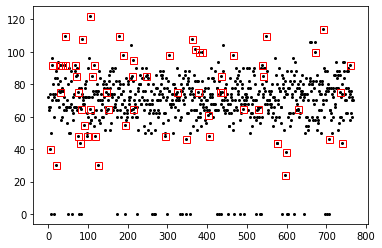

Attribute BloodPressure has [ 24  30  38  40  44  46  48  55  61  65  75  85  92  95  98 100 102 108
 110 114 122] as outliers


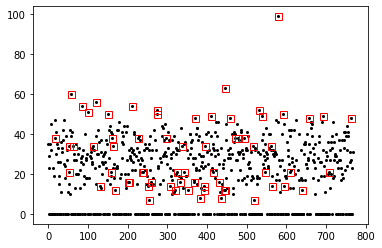

Attribute SkinThickness has [ 7  8 12 14 16 21 34 38 48 49 50 51 52 54 56 60 63 99] as outliers


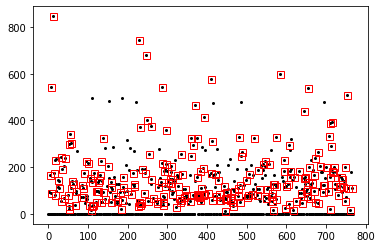

Attribute Insulin has [ 14  15  16  18  22  23  25  29  32  36  37  38  40  41  45  46  49  51
  52  53  54  55  57  58  59  60  61  63  67  68  70  71  72  73  75  77
  78  79  81  82  83  84  85  86  87  88  91  92  95  99 100 106 108 110
 112 114 116 120 125 126 127 128 129 132 135 142 145 146 148 150 152 158
 159 160 168 170 171 175 176 178 182 183 184 185 188 192 196 200 204 205
 215 220 225 228 230 240 245 249 250 255 258 265 291 293 300 304 310 325
 326 328 330 335 342 360 370 375 387 392 402 415 440 465 510 540 543 545
 579 600 680 744 846] as outliers


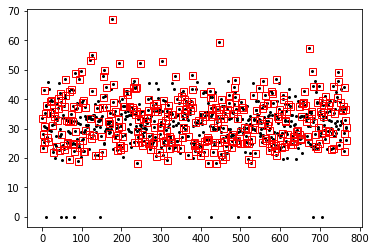

Attribute BMI has [18.2 18.4 19.1 19.3 19.6 20.8 21.  21.1 21.2 21.7 21.9 22.2 22.3 22.4
 22.5 22.6 22.7 22.9 23.  23.3 23.5 23.7 23.8 23.9 24.  24.1 24.3 24.4
 24.5 24.7 24.9 25.  25.1 25.3 25.4 25.5 25.6 25.8 25.9 26.1 26.2 26.3
 26.4 26.7 26.8 26.9 27.  27.1 27.2 27.3 27.5 27.9 28.  28.1 28.2 28.3
 28.4 29.2 29.3 29.5 29.8 30.2 30.3 30.4 30.7 31.  31.1 31.3 31.9 32.1
 32.2 32.3 32.5 32.6 32.9 33.1 33.5 33.6 34.1 34.4 35.  35.1 35.2 35.3
 35.4 35.9 36.  36.1 36.2 36.3 36.5 36.7 36.8 36.9 37.  37.1 37.2 37.3
 37.4 37.5 37.7 37.8 37.9 38.  38.1 38.4 38.6 38.7 38.8 38.9 39.  39.1
 39.2 39.3 39.6 39.7 39.8 39.9 40.  40.1 40.2 40.6 40.7 41.  41.2 41.3
 41.5 41.8 42.  42.1 42.6 42.7 42.8 42.9 43.1 43.4 43.6 44.  44.1 44.2
 44.5 44.6 45.  46.2 46.3 46.5 46.7 46.8 47.9 48.3 48.8 49.3 49.6 49.7
 50.  52.3 52.9 53.2 55.  57.3 59.4 67.1] as outliers


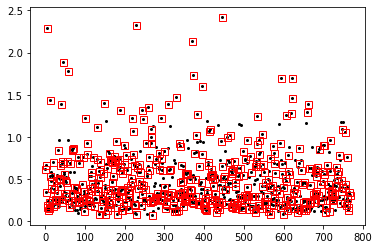

Attribute DiabetesPedigreeFunction has [0.078 0.084 0.085 0.088 0.089 0.107 0.108 0.115 0.118 0.121 0.122 0.123
 0.13  0.133 0.134 0.135 0.136 0.137 0.138 0.142 0.145 0.147 0.151 0.154
 0.155 0.156 0.157 0.158 0.159 0.16  0.161 0.162 0.167 0.17  0.171 0.173
 0.174 0.175 0.176 0.177 0.183 0.186 0.187 0.192 0.194 0.196 0.197 0.198
 0.201 0.203 0.204 0.205 0.209 0.21  0.212 0.215 0.217 0.219 0.222 0.225
 0.226 0.227 0.229 0.23  0.231 0.232 0.233 0.234 0.235 0.237 0.239 0.24
 0.241 0.243 0.244 0.246 0.247 0.249 0.251 0.252 0.253 0.254 0.255 0.256
 0.257 0.262 0.263 0.264 0.265 0.267 0.271 0.272 0.277 0.278 0.279 0.28
 0.287 0.289 0.29  0.292 0.296 0.297 0.299 0.3   0.302 0.305 0.307 0.313
 0.314 0.315 0.317 0.318 0.319 0.326 0.328 0.329 0.331 0.332 0.334 0.336
 0.337 0.342 0.343 0.345 0.346 0.347 0.349 0.351 0.352 0.355 0.356 0.358
 0.361 0.366 0.368 0.371 0.374 0.375 0.376 0.378 0.38  0.381 0.382 0.383
 0.385 0.388 0.391 0.393 0.394 0.398 0.399 0.404 0.407 0.408 0.409 0.411
 0.412 0.419 0

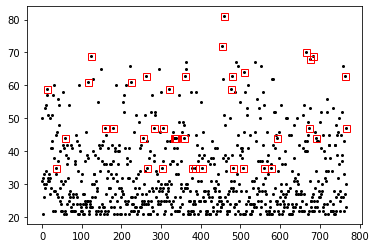

Attribute Age has [35 44 47 59 61 63 64 68 69 70 72 81] as outliers


In [48]:
# Now, we iterate over the columns and find the outliers in each column
for col in df_pid.columns[:-1]:
    data = np.array(df_pid[col])
    outliers = lof_outliers(data, 1.0)
    print("Attribute {} has {} as outliers".format(col, outliers))

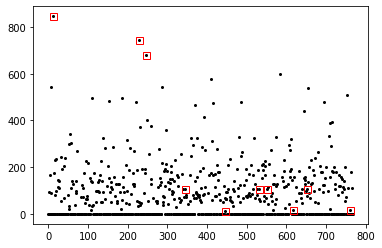

Attribute Insulin has [ 14  15  16 106 108 680 744 846] as outliers
Number of outliers =  8


In [50]:
# We need to handle the columns Insulin, BMI and DiabetesPedigreeFunction separately
# We need to handle the attribute Insulin Separately with different threshold values
col = 'Insulin'
data = np.array(df_pid[col])
outliers = lof_outliers(data, 2)
print("Attribute {} has {} as outliers".format(col, outliers))
print ("Number of outliers = ", len(outliers))

In [ ]:
import numpy as np
import math
from sklearn.datasets import load_iris
from sklearn import datasets, linear_model, metrics

# load iris data set
dataset = load_iris()
a = dataset.data
b = np.zeros(150)

# take 1st column among 4 column of data set
for i in range (150):
	b[i]=a[i,1]

b=np.sort(b) #sort the array

# create bins
bin1=np.zeros((30,5))
bin2=np.zeros((30,5))
bin3=np.zeros((30,5))

# Bin mean
for i in range (0,150,5):
	k=int(i/5)
	mean=(b[i] + b[i+1] + b[i+2] + b[i+3] + b[i+4])/5
	for j in range(5):
		bin1[k,j]=mean
print("Bin Mean: \n",bin1)
	
# Bin boundaries
for i in range (0,150,5):
	k=int(i/5)
	for j in range (5):
		if (b[i+j]-b[i]) < (b[i+4]-b[i+j]):
			bin2[k,j]=b[i]
		else:
			bin2[k,j]=b[i+4]
print("Bin Boundaries: \n",bin2)

# Bin median
for i in range (0,150,5):
	k=int(i/5)
	for j in range (5):
		bin3[k,j]=b[i+2]
print("Bin Median: \n",bin3)